In [58]:
from manim import *
import numpy as np

def param_uvplane_rotated(x, y, ang_x=0, ang_y=0):
    # Parametrize a plane rotated about the u and v axes
    z = np.tan(ang_y) * x + np.tan(ang_x) * y
    return np.array([x, y, z])

def uv_normal_unit_vector(ang_x, ang_y):
    x = np.sin(ang_y)
    y = np.sin(ang_x)
    z = np.sqrt(1 - x**2 - y**2)
    return np.array([x, y, z])
    

class ThreeDuvCoordinatePlot(ThreeDScene):
    def construct(self):
        resolution_fa = 24
        self.set_camera_orientation(phi=75 * DEGREES, theta=-30 * DEGREES)

        # Angle of rotation (i.e. angle between zenith and tracking center)
        ang_x = np.deg2rad(-20)
        ang_y = np.deg2rad(0)
        def param_uvplane(u, v):
            return param_uvplane_rotated(u, v, ang_x, ang_y)
        
        # Initialize u-v surface
        uv_scale = 2
        uv_len = 2
        uv_range = [-uv_len, +uv_len]
        uv_plane = Surface(
            param_uvplane,
            resolution=(resolution_fa, resolution_fa),
            v_range=uv_range,
            u_range=uv_range,
        )
        uv_plane.scale(uv_scale, about_point=ORIGIN)
        uv_plane.set_style(fill_opacity=1,stroke_color=GREEN)
        uv_plane.set_fill_by_checkerboard(ORANGE, BLUE, opacity=0.2)

        # Manually initialize u-v axes as a set of arrows
        uv_axes = VGroup()
        uv_axes.add(Arrow3D(
            start=param_uvplane(-uv_len*uv_scale, 0),
            end=param_uvplane(+uv_len*uv_scale, 0), 
            color=BLUE
        ))
        uv_axes.add(Arrow3D(
            start=param_uvplane(0, -uv_len*uv_scale),
            end=param_uvplane(0, +uv_len*uv_scale), 
            color=BLUE
        ))
        e_z = uv_normal_unit_vector(ang_x, ang_y)
        uv_axes.add(Arrow3D(
            start=-e_z * uv_len * uv_scale,
            end=e_z * uv_len * uv_scale,
            color=BLUE
        ))

        # Initialize local axes
        axes = ThreeDAxes()

        # Add elements to scene
        # self.add(axes, uv_plane, uv_axes)
        self.add(axes, uv_plane, uv_axes)



        # Camera rotation (actual animation part)
        duration = 2 # seconds
        # self.begin_ambient_camera_rotation(rate=2*PI/duration, about="theta")
        # self.wait(duration=duration)


Manim Community v0.18.1

[11/06/24 17:21:25] INFO                                                                   ]8;id=557704;file:///hs/fs08/data/group-brueggen/tmartinez/envs/cenv_diffusion/lib/python3.11/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=304569;file:///hs/fs08/data/group-brueggen/tmartinez/envs/cenv_diffusion/lib/python3.11/site-packages/manim/scene/scene_file_writer.py#737\737]8;;\
                             File ready at                                                                         
                             '/hs/fs08/data/group-brueggen/tmartinez/diffusion/src/noteboo                         
                             ks/media/images/notebooks/ThreeDuvCoordinatePlot_ManimCE_v0.1                         
                             8.1.png'                                                                              
                                                                                                                   

                    INFO     Rendered ThreeDuvCoordinatePlot                                           ]8;id=27518;file:///hs/fs08/data/group-brueggen/tmartinez/envs/cenv_diffusion/lib/python3.11/site-packages/manim/scene/scene.py\scene.py]8;;\:]8;id=800044;file:///hs/fs08/data/group-brueggen/tmartinez/envs/cenv_diffusion/lib/python3.11/site-packages/manim/scene/scene.py#247\247]8;;\
                             Played 0 animations                                                                   

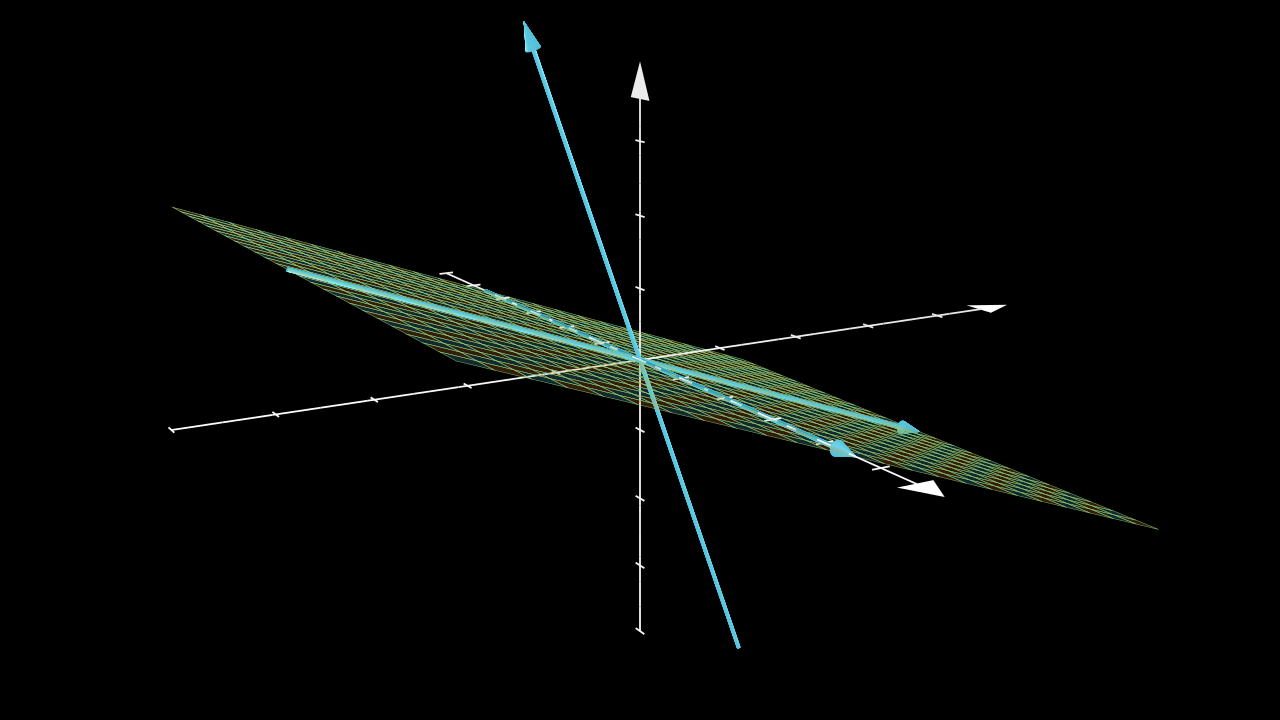

In [59]:
%manim -qm ThreeDuvCoordinatePlot